In [4]:
import pickle
import os
from collections import defaultdict
def load_graphs(path):
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data

def save_results(results, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(results, f)

def to_dict(obj):
    if isinstance(obj, defaultdict):
        return {k: to_dict(v) for k, v in obj.items()}
    return obj

In [5]:
size = 1
for m in [3, 5, 9]:
    if not os.path.exists(f"fig_data/fig11/fig11_m{m:02d}.pkl"):
        raise FileNotFoundError(f"Data file for m={m} not found. Please run the simulation to generate the data.")

Fig 11a


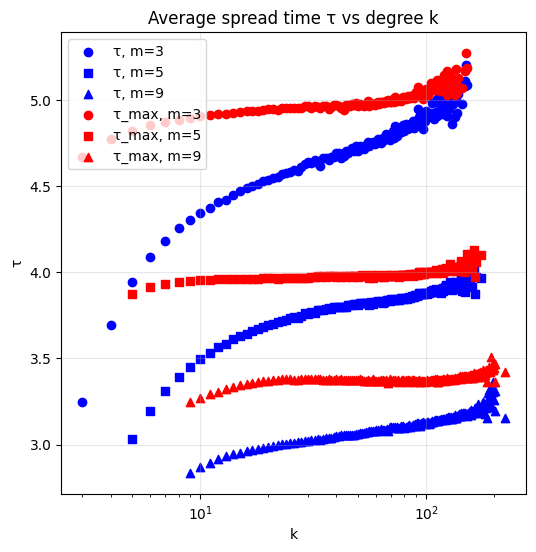

In [8]:
import matplotlib.pyplot as plt
import numpy as np

markers = {
    3: "o",   # circle
    5: "s",   # square
    9: "^",   # triangle
}

#Spread time
plt.figure(figsize=(6, 6))
for m in [3, 5, 9]:
    BA_data_by_k = load_graphs(f"fig_data/fig11/fig11_m{m:02d}.pkl")
    BA_plot_data_by_k = defaultdict(dict)
    for k in BA_data_by_k:
        BA_plot_data_by_k[k]["spread_time"] = sum(BA_data_by_k[k]["spread_time"]) / len(BA_data_by_k[k]["spread_time"])
    ks = np.array(sorted(BA_plot_data_by_k))
    spread_times = np.array([BA_plot_data_by_k[k]["spread_time"] for k in ks])

    plt.scatter(ks, spread_times, color="blue", label=f"τ, m={m}", marker=markers[m])
    del BA_data_by_k, BA_plot_data_by_k

for m in [3, 5, 9]:
    BA_data_by_k = load_graphs(f"fig_data/fig11/fig11_m{m:02d}.pkl")
    BA_plot_data_by_k = defaultdict(dict)
    for k in BA_data_by_k:
        BA_plot_data_by_k[k]["time"] = sum(BA_data_by_k[k]["time"]) / len(BA_data_by_k[k]["time"])
    ks = np.array(sorted(BA_plot_data_by_k))
    spread_times = np.array([BA_plot_data_by_k[k]["time"] for k in ks])

    plt.scatter(ks, spread_times, color="red", label=f"τ_max, m={m}", marker=markers[m])
    del BA_data_by_k, BA_plot_data_by_k

print("Fig 11a")
plt.xscale("log")
plt.xlabel("k")
plt.ylabel("τ")
plt.title("Average spread time τ vs degree k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Fig 11b


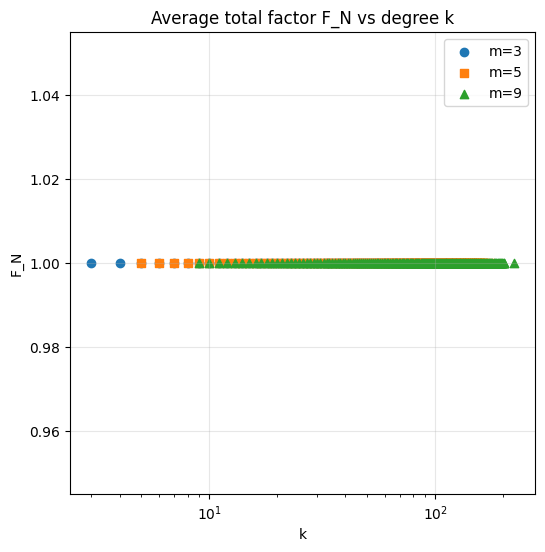

In [9]:
#Spread factor
plt.figure(figsize=(6, 6))
for m in [3, 5, 9]:
    BA_data_by_k = load_graphs(f"fig_data/fig11/fig11_m{m:02d}.pkl")
    BA_plot_data_by_k = defaultdict(dict) 
    for k in BA_data_by_k: 
        BA_plot_data_by_k[k]["total_factor"] = sum(BA_data_by_k[k]["total_factor"]) / len(BA_data_by_k[k]["total_factor"])
    ks = sorted(BA_plot_data_by_k)
    spread_factors = [BA_plot_data_by_k[k]["total_factor"]for k in ks]
    plt.scatter(ks, spread_factors, marker=markers[m], label=f"m={m}")
    del BA_data_by_k, BA_plot_data_by_k

print("Fig 11b")
plt.xscale("log")
plt.xlabel("k")
plt.ylabel("F_N")
plt.title("Average total factor F_N vs degree k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()